In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_s
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Flatten,
    MaxPooling1D,
    Dropout
)

from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

# Load Dataset

In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

print(df.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

# Dataset Info

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

# Data Cleaning

In [4]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):

        df[col] = df[col].fillna(df[col].median())

    else:

        df[col] = df[col].fillna(df[col].mode()[0])

# Encode Country

In [5]:
le = LabelEncoder()

df["Country"] = le.fit_transform(
    df["Country"]
)

# Feature Engineering

In [6]:
df["Energy_Per_Capita"] = (

    df["Energy_Consumption_Per_Capita (in MWh)"]

    /

    df["Population (in millions)"]

)

# Average Pollution Index

In [7]:
df["Avg_Pollution"] = (

    df["Air_Pollution_Index"]

    +

    df["Water_Pollution_Index"]

    +

    df["Soil_Pollution_Index"]

) / 3

# Pollution Severity

In [8]:
df["Pollution_Severity"] = pd.cut(

    df["Avg_Pollution"],

    bins=[0,40,70,100],

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

# Correlation Heatmap

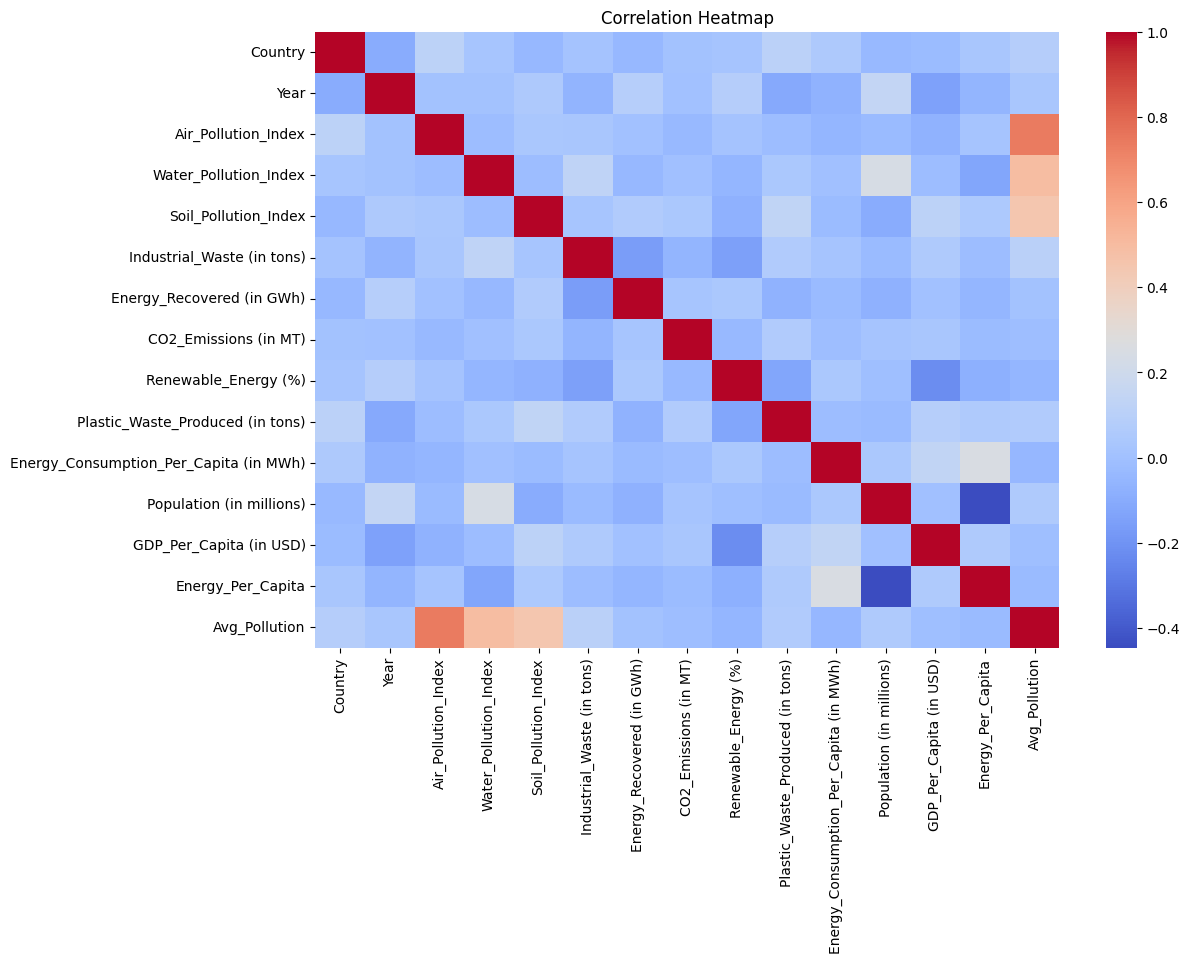

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Correlation With Target

In [26]:
corr = df.corr(
    numeric_only=True
)[
    "Energy_Recovered (in GWh)"
]

print(
    corr.sort_values(
        ascending=False
    )
)

Energy_Recovered (in GWh)                 1.000000
Year                                      0.088332
Soil_Pollution_Index                      0.064076
Renewable_Energy (%)                      0.043533
CO2_Emissions (in MT)                     0.024758
Avg_Pollution                             0.008273
GDP_Per_Capita (in USD)                   0.004535
Air_Pollution_Index                       0.002997
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Water_Pollution_Index                    -0.041828
Country                                  -0.044316
Energy_Per_Capita                        -0.053326
Plastic_Waste_Produced (in tons)         -0.072946
Population (in millions)                 -0.075100
Industrial_Waste (in tons)               -0.161309
Name: Energy_Recovered (in GWh), dtype: float64


# Scatter Plot

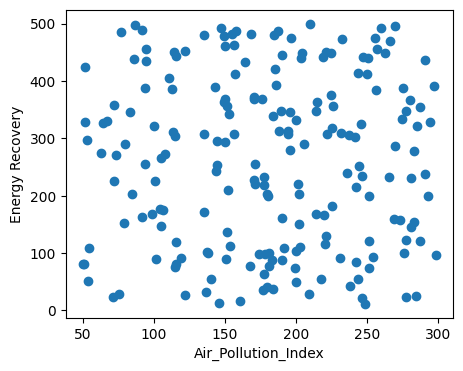

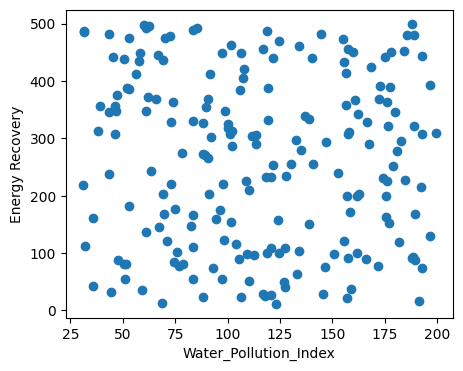

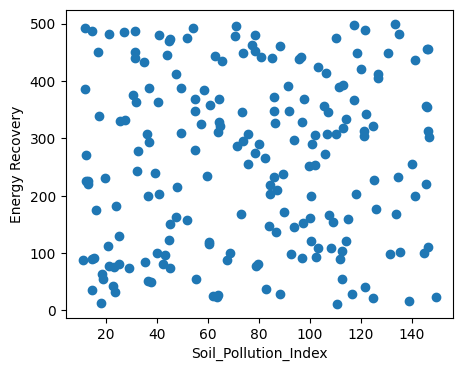

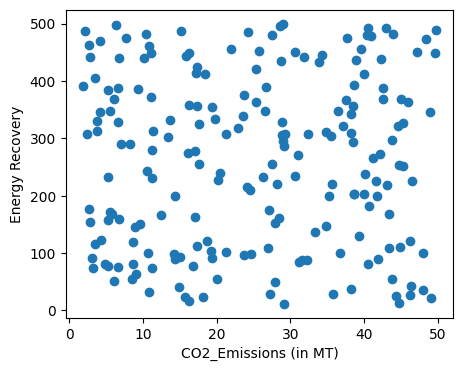

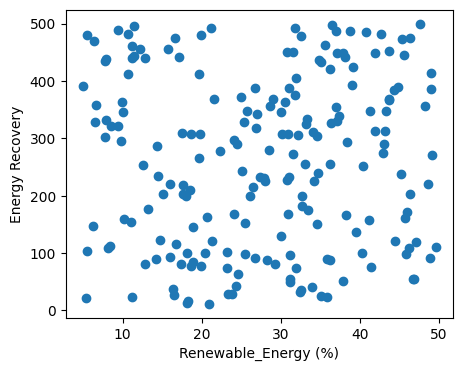

In [11]:
cols = [

"Air_Pollution_Index",

"Water_Pollution_Index",

"Soil_Pollution_Index",

"CO2_Emissions (in MT)",

"Renewable_Energy (%)"

]

for col in cols:

    plt.figure(figsize=(5,4))

    plt.scatter(
        df[col],
        df["Energy_Recovered (in GWh)"]
    )

    plt.xlabel(col)

    plt.ylabel(
        "Energy Recovery"
    )

    plt.show()

# Apriori Algorithm

In [25]:
apriori_df = pd.DataFrame()

apriori_df["High_Air"] = np.where(
    df["Air_Pollution_Index"] > 70,
    1,
    0
)

apriori_df["High_Water"] = np.where(
    df["Water_Pollution_Index"] > 70,
    1,
    0
)

apriori_df["High_Soil"] = np.where(
    df["Soil_Pollution_Index"] > 70,
    1,
    0
)

apriori_df["High_CO2"] = np.where(
    df["CO2_Emissions (in MT)"] > 70,
    1,
    0
)

apriori_df["High_EnergyRecovery"] = np.where(
    df["Energy_Recovered (in GWh)"] > 500,
    1,
    0
)

# Apriori

In [24]:
frequent_items = apriori(

    apriori_df,

    min_support=0.10,

    use_colnames=True
)

frequent_items


c:\Users\sachin p singh\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.950,frozenset({High_Air})
1,0.775,frozenset({High_Water})
2,0.560,frozenset({High_Soil})
3,0.500,frozenset({High_EnergyRecovery})
4,0.735,"frozenset({High_Air, High_Water})"
5,0.530,"frozenset({High_Air, High_Soil})"
6,0.470,"frozenset({High_EnergyRecovery, High_Air})"
7,0.440,"frozenset({High_Water, High_Soil})"
8,0.365,"frozenset({High_EnergyRecovery, High_Water})"
9,0.295,"frozenset({High_EnergyRecovery, High_Soil})"


# Association Rules

In [14]:
rules = association_rules(

    frequent_items,

    metric="confidence",

    min_threshold=0.5
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({High_Air}),frozenset({High_Water}),0.950,0.775,0.735,0.773684,0.998302,1.0,-0.00125,0.994186,-0.032895,0.742424,-0.005848,0.861036
1,frozenset({High_Water}),frozenset({High_Air}),0.775,0.950,0.735,0.948387,0.998302,1.0,-0.00125,0.968750,-0.007502,0.742424,-0.032258,0.861036
2,frozenset({High_Air}),frozenset({High_Soil}),0.950,0.560,0.530,0.557895,0.996241,1.0,-0.00200,0.995238,-0.070175,0.540816,-0.004785,0.752162
3,frozenset({High_Soil}),frozenset({High_Air}),0.560,0.950,0.530,0.946429,0.996241,1.0,-0.00200,0.933333,-0.008503,0.540816,-0.071429,0.752162
4,frozenset({High_Water}),frozenset({High_Soil}),0.775,0.560,0.440,0.567742,1.013825,1.0,0.00600,1.017910,0.060606,0.491620,0.017595,0.676728
5,frozenset({High_Soil}),frozenset({High_Water}),0.560,0.775,0.440,0.785714,1.013825,1.0,0.00600,1.050000,0.030992,0.491620,0.047619,0.676728
6,"frozenset({High_Air, High_Water})",frozenset({High_Soil}),0.735,0.560,0.415,0.564626,1.008260,1.0,0.00340,1.010625,0.030916,0.471591,0.010513,0.652849
7,"frozenset({High_Air, High_Soil})",frozenset({High_Water}),0.530,0.775,0.415,0.783019,1.010347,1.0,0.00425,1.036957,0.021789,0.466292,0.035639,0.659251
8,"frozenset({High_Water, High_Soil})",frozenset({High_Air}),0.440,0.950,0.415,0.943182,0.992823,1.0,-0.00300,0.880000,-0.012744,0.425641,-0.136364,0.690012
9,frozenset({High_Water}),"frozenset({High_Air, High_Soil})",0.775,0.530,0.415,0.535484,1.010347,1.0,0.00425,1.011806,0.045515,0.466292,0.011668,0.659251


# Support Confidence Lift

In [15]:
rules[

[
"antecedents",

"consequents",

"support",

"confidence",

"lift"

]

].sort_values(

    by="lift",

    ascending=False

)

,antecedents,consequents,support,confidence,lift
5,frozenset({High_Soil}),frozenset({High_Water}),0.440,0.785714,1.013825
4,frozenset({High_Water}),frozenset({High_Soil}),0.440,0.567742,1.013825
9,frozenset({High_Water}),"frozenset({High_Air, High_Soil})",0.415,0.535484,1.010347
7,"frozenset({High_Air, High_Soil})",frozenset({High_Water}),0.415,0.783019,1.010347
10,frozenset({High_Soil}),"frozenset({High_Air, High_Water})",0.415,0.741071,1.008260
6,"frozenset({High_Air, High_Water})",frozenset({High_Soil}),0.415,0.564626,1.008260
0,frozenset({High_Air}),frozenset({High_Water}),0.735,0.773684,0.998302
1,frozenset({High_Water}),frozenset({High_Air}),0.735,0.948387,0.998302
2,frozenset({High_Air}),frozenset({High_Soil}),0.530,0.557895,0.996241
3,frozenset({High_Soil}),frozenset({High_Air}),0.530,0.946429,0.996241


# Lift Visualization

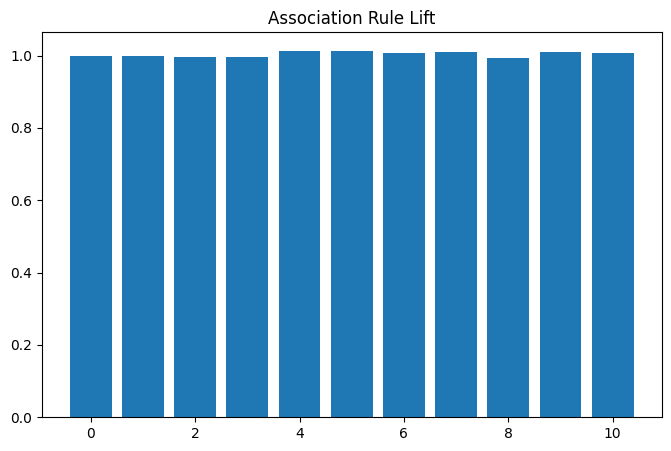

In [16]:
plt.figure(figsize=(8,5))

plt.bar(

    range(len(rules)),

    rules["lift"]

)

plt.title(
    "Association Rule Lift"
)

plt.show()

# Pollution Normalization

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
pollution_cols = ["Air_Pollution_Index","Water_Pollution_Index","Soil_Pollution_Index"]

df[pollution_cols] = scaler.fit_transform(df[pollution_cols])
df[pollution_cols].head()


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
0,0.898042,0.553778,0.295481
1,0.147062,0.173673,0.768178
2,0.166727,0.310542,0.800768
3,0.929982,0.214222,0.596973
4,0.520331,0.573161,0.799537


# Energy Recovery Based Association Rules

In [18]:
apriori_df["High_EnergyRecovery"] = np.where(
    df["Energy_Recovered (in GWh)"] >
    df["Energy_Recovered (in GWh)"].median(),1,0)

frequent_items = apriori(apriori_df,min_support=0.10,use_colnames=True)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

energy_rules = rules[
    rules["consequents"].astype(str).str.contains("High_EnergyRecovery")
]

energy_rules[["antecedents","consequents","support","confidence","lift"]].sort_values(
    by="lift",ascending=False)


c:\Users\sachin p singh\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,support,confidence,lift
9,frozenset({High_Soil}),frozenset({High_EnergyRecovery}),0.295,0.526786,1.053571
20,"frozenset({High_Air, High_Soil})",frozenset({High_EnergyRecovery}),0.275,0.518868,1.037736


# Support vs Confidence Visualization

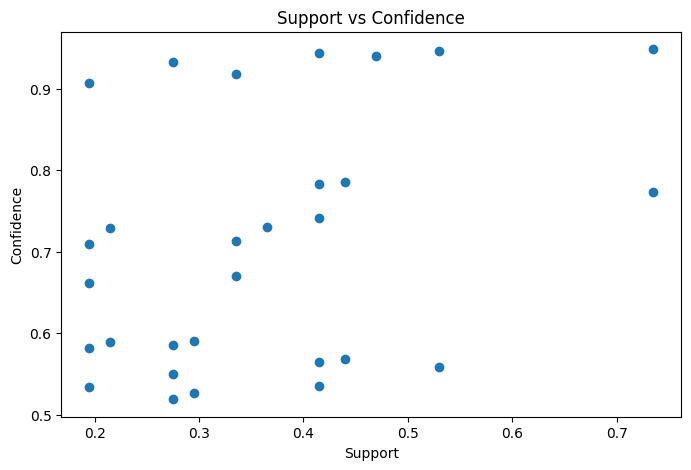

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(rules["support"], rules["confidence"])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()


# Association Rule Network Graph

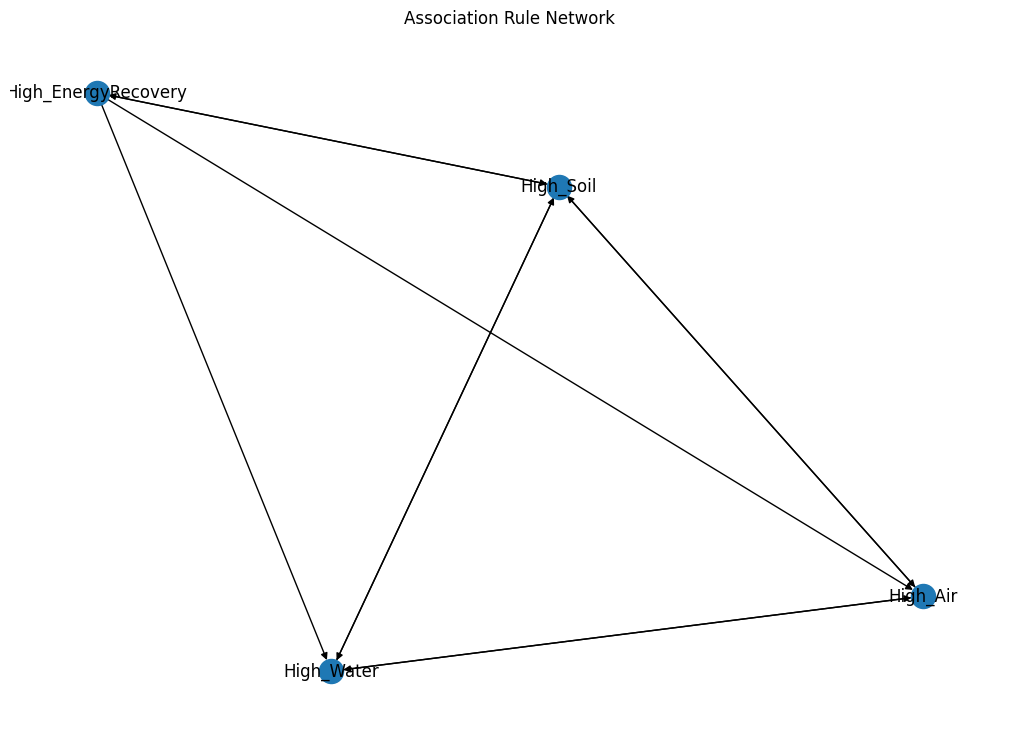

In [21]:
import networkx as nx

G = nx.DiGraph()
for _, row in rules.head(20).iterrows():
    for a in row["antecedents"]:
        for c in row["consequents"]:
            G.add_edge(a,c,weight=row["lift"])

plt.figure(figsize=(10,7))
nx.draw(G, with_labels=True)
plt.title("Association Rule Network")
plt.show()


# Lift Interpretation

In [22]:
print('Lift > 1 : Positive Association')
print('Lift = 1 : No Association')
print('Lift < 1 : Negative Association')

rules[['antecedents','consequents','lift']].sort_values(
    by='lift',ascending=False).head(10)


Lift > 1 : Positive Association
Lift = 1 : No Association
Lift < 1 : Negative Association


,antecedents,consequents,lift
8,frozenset({High_EnergyRecovery}),frozenset({High_Soil}),1.053571
9,frozenset({High_Soil}),frozenset({High_EnergyRecovery}),1.053571
22,"frozenset({High_EnergyRecovery, High_Water})",frozenset({High_Soil}),1.051859
18,"frozenset({High_EnergyRecovery, High_Air})",frozenset({High_Soil}),1.044833
24,"frozenset({High_EnergyRecovery, High_Air, High...",frozenset({High_Soil}),1.039446
20,"frozenset({High_Air, High_Soil})",frozenset({High_EnergyRecovery}),1.037736
21,frozenset({High_EnergyRecovery}),"frozenset({High_Air, High_Soil})",1.037736
6,frozenset({High_Soil}),frozenset({High_Water}),1.013825
5,frozenset({High_Water}),frozenset({High_Soil}),1.013825
13,frozenset({High_Water}),"frozenset({High_Air, High_Soil})",1.010347


# Country Specific Analysis

In [23]:
country_analysis = df.groupby("Country").agg({
    "Air_Pollution_Index":"mean",
    "Water_Pollution_Index":"mean",
    "Soil_Pollution_Index":"mean",
    "Energy_Recovered (in GWh)":"mean"
})

country_analysis.sort_values(
    by="Energy_Recovered (in GWh)",
    ascending=False
).head(10)


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Country,,,,
31,0.642479,0.933528,0.886081,499.98
147,0.147062,0.173673,0.768178,498.04
156,0.885645,0.185504,0.434820,495.28
54,0.843933,0.179202,0.004490,493.12
72,0.391601,0.321898,0.312790,492.08
98,0.553604,0.522921,0.147958,487.84
85,0.434363,0.001784,0.023827,486.72
30,0.106400,0.003151,0.115513,484.72
169,0.423461,0.674654,0.073001,480.99


# Methodology


1. Data Collection  
2. Data Cleaning & Missing Value Handling  
3. Pollution Index Normalization  
4. Feature Engineering  
5. Transaction Creation for Apriori  
6. Frequent Itemset Mining  
7. Association Rule Generation  
8. Support, Confidence and Lift Evaluation  
9. Country Specific Analysis  
10. Recommendations


# Final Findings

- Pollution indices normalized before analysis.
- Apriori rules evaluated for Pollution vs Energy Recovery.
- Support, Confidence and Lift analyzed.
- Network graph and scatter plot generated.
- Country-specific pollution and energy recovery trends examined.
- CNN section removed because it is outside the scope of Apriori analysis.
